In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.markers as mmarkers
import pandas as pd
from dataclasses import dataclass
from markdown_pdf import MarkdownPdf, Section as MdSection
import re
import os

In [ ]:
project_path = r"C:\Users\student\Desktop\Mann11CellLines_HelaOnly_RawOnly\All18rawfiles\2026-04-07-16-56-28"
figure_save_path = os.path.join(project_path, "Figures")
fn = os.path.join(project_path, "Task1-SearchTask", "AllQuantifiedProteinGroups.tsv")

if not os.path.exists(figure_save_path):
    os.makedirs(figure_save_path)

df = pd.read_csv(fn, sep="\t")
print(f"Column names: {df.columns.tolist()}")

occupancy_columns = [col for col in df.columns if 'CountOccupancy' in col]
has_intensity_occupancy = any('IntensityOccupancy' in col for col in df.columns)
conditions = set([col.split('_')[1] for col in occupancy_columns])
bioreps = set([col.split('_')[2] for col in occupancy_columns])
print(f"Number of occupancy columns: {len(occupancy_columns)}")
print(f"Has IntensityOccupancy columns: {has_intensity_occupancy}")
print(f"Conditions = {conditions}")
print(f"Biological replicates = {bioreps}")

Column names: ['Protein Accession', 'Gene', 'Organism', 'Protein Full Name', 'Protein Unmodified Mass', 'Number of Proteins in Group', 'Unique Peptides', 'Shared Peptides', 'Number of Peptides', 'Number of Unique Peptides', 'Sequence Coverage Fraction', 'Sequence Coverage', 'Sequence Coverage with Mods', 'Fragment Sequence Coverage', 'SpectralCount_1_1', 'Intensity_1_1', 'CountOccupancy_1_1', 'IntensityOccupancy_1_1', 'SpectralCount_1_2', 'Intensity_1_2', 'CountOccupancy_1_2', 'IntensityOccupancy_1_2', 'SpectralCount_1_3', 'Intensity_1_3', 'CountOccupancy_1_3', 'IntensityOccupancy_1_3', 'Number of PSMs', 'Protein Decoy/Contaminant/Target', 'Protein Cumulative Target', 'Protein Cumulative Decoy', 'Protein QValue', 'Best Peptide Score', 'Best Peptide Notch QValue', 'Best Peptide PEP']
Number of occupancy columns: 3
Has IntensityOccupancy columns: True
Conditions = {'1'}
Biological replicates = {'1', '2', '3'}


In [ ]:
@dataclass
class Modification:
    name: str
    position: int
    spectral_count: int
    total_counts_at_position: int
    intensity: float
    total_intensity_at_position: float

@dataclass
class ProteinGroup:
    id: str
    proteins: list[str]
    modifications: dict[str, list[Modification]]  # keyed by protein, value is list of Modification
    intensity: float

psm_mod_regex = r"pos(\d+)\[(.+),info:fraction=.+\((.+)/(.+)\)\]"
intensity_mod_regex = r"pos(\d+)\[(.+),info:fraction=.+\((.+)/(.+)\)\]"

def extract_modified_pgs(df, filter_by_qvalue=True, qvalue_threshold=0.01, keep_first_protein_only=True) -> dict[str, list[ProteinGroup]]:
    result: dict[str, list[ProteinGroup]] = {}
    psm_occ_cols = [col for col in df.columns if 'CountOccupancy' in col]
    int_occ_cols = [col for col in df.columns if 'IntensityOccupancy' in col]

    filtered_df = df[df["Protein QValue"] <= qvalue_threshold] if filter_by_qvalue else df

    for _, row in filtered_df.iterrows():
        pg_id = row["Protein Accession"]
        all_proteins = pg_id.split("|")
        proteins = [all_proteins[0]] if keep_first_protein_only else all_proteins

        for col in psm_occ_cols:
            cond_biorep = "_".join(col.split('_')[1:])

            if pd.isna(row[col]):
                continue

            psm_occupancy = row[col].split("|")
            int_col = col.replace("CountOccupancy", "IntensityOccupancy")
            intensity_occupancy = row[int_col].split("|") if int_occ_cols and pd.notna(row[int_col]) else [None] * len(psm_occupancy)

            modifications = {}
            for prot_idx, protein in enumerate(proteins):
                if prot_idx >= len(psm_occupancy):
                    break
                psm_mods = psm_occupancy[prot_idx].split(";")
                int_mods = intensity_occupancy[prot_idx].split(";") if intensity_occupancy[prot_idx] else []

                mods = []
                for mod_idx, psm_mod_str in enumerate(psm_mods):
                    psm_match = re.match(psm_mod_regex, psm_mod_str)
                    if not psm_match:
                        continue
                    int_match = re.match(intensity_mod_regex, int_mods[mod_idx]) if mod_idx < len(int_mods) else None
                    mods.append(Modification(
                        name=psm_match.group(2),
                        position=int(psm_match.group(1)),
                        spectral_count=int(psm_match.group(3)),
                        total_counts_at_position=int(psm_match.group(4)),
                        intensity=float(int_match.group(3)) if int_match else 0.0,
                        total_intensity_at_position=float(int_match.group(4)) if int_match else 0.0
                    ))
                modifications[protein] = mods

            pg = ProteinGroup(
                id=pg_id,
                proteins=proteins,
                modifications=modifications,
                intensity=row[f"Intensity_{cond_biorep}"] if f"Intensity_{cond_biorep}" in row else 0.0
            )

            result.setdefault(cond_biorep, []).append(pg)

    return result


#extract_modified_pgs(df)

In [ ]:
Q_Value_threshold = 0.01
figure_dpi = 200
save_figures = True
save_summary = True

In [ ]:
modified_pgs_per_condbiorep = extract_modified_pgs(df, qvalue_threshold=Q_Value_threshold)
for cond_biorep, pgs in modified_pgs_per_condbiorep.items():
    print(f"Condition/Biorep: {cond_biorep}, Number of modified PGs: {len(pgs)} / {df[(df[f'SpectralCount_{cond_biorep}'] > 0) & (df['Protein QValue'] <= Q_Value_threshold)].shape[0]}")
print(f"Total number of PGs: {df.shape[0]}")
print(f"Total number of PGs below {Q_Value_threshold}-Qvalue: {df[df['Protein QValue'] <= Q_Value_threshold].shape[0]}")
total_modifications = sum(len(mods) for pgs in modified_pgs_per_condbiorep.values() for pg in pgs for mods in pg.modifications.values())
print(f"Total number of modified-sites observed across all PGs and conditions/bioreps: {total_modifications}")
print(f"Unique modified sites by protein and position: {len(set((protein, mod.position) for pgs in modified_pgs_per_condbiorep.values() for pg in pgs for protein, mods in pg.modifications.items() for mod in mods))}")


Condition/Biorep: 1_1, Number of modified PGs: 675 / 6378
Condition/Biorep: 1_2, Number of modified PGs: 426 / 5529
Condition/Biorep: 1_3, Number of modified PGs: 1269 / 7027
Total number of PGs: 9338
Total number of PGs below 0.01-Qvalue: 7323
Total number of modified-sites observed across all PGs and conditions/bioreps: 4875
Unique modified sites by protein and position: 3553


In [ ]:
"""
pgs_with_mods = []
for _, row in df[df["Protein QValue"] <= 0.01].iterrows():
    id = row["Protein Accession"]
    proteins = row["Protein Accession"].split("|")
    intensity = row["Intensity_1_1"]

    assert type(row["CountOccupancy_1_1"]) == type(row["IntensityOccupancy_1_1"])

    if pd.notna(row["CountOccupancy_1_1"]) and pd.notna(row["IntensityOccupancy_1_1"]):

        assert row["CountOccupancy_1_1"].count("|") + 1 == row["IntensityOccupancy_1_1"].count("|") + 1 == len(proteins)

        psm_occupancy = row["CountOccupancy_1_1"].split("|")
        intensity_occupancy = row["IntensityOccupancy_1_1"].split("|")
        modifications = {}
        for prot_index in range(len(proteins)):
            psm_mods = psm_occupancy[prot_index].split(";")
            intensity_mods = intensity_occupancy[prot_index].split(";")
        
            assert len(psm_mods) == len(intensity_mods)

            mods = []
            for mod_index in range(len(psm_mods)):
                psm_mod = re.match(psm_mod_regex, psm_mods[mod_index])
                intensity_mod = re.match(intensity_mod_regex, intensity_mods[mod_index])

                assert psm_mod is not None and intensity_mod is not None
                assert psm_mod.group(1) == intensity_mod.group(1)
                assert psm_mod.group(2) == intensity_mod.group(2)

                mods.append(Modification(
                    name=psm_mod.group(2),
                    position=int(psm_mod.group(1)),
                    spectral_count=int(psm_mod.group(3)),
                    total_counts_at_position=int(psm_mod.group(4)),
                    intensity=float(intensity_mod.group(3)),
                    total_intensity_at_position=float(intensity_mod.group(4))
                ))
            
            modifications[proteins[prot_index]] = mods
        pgs_with_mods.append(ProteinGroup(id=id, proteins=proteins, modifications=modifications, intensity=intensity))
"""

'\npgs_with_mods = []\nfor _, row in df[df["Protein QValue"] <= 0.01].iterrows():\n    id = row["Protein Accession"]\n    proteins = row["Protein Accession"].split("|")\n    intensity = row["Intensity_1_1"]\n\n    assert type(row["CountOccupancy_1_1"]) == type(row["IntensityOccupancy_1_1"])\n\n    if pd.notna(row["CountOccupancy_1_1"]) and pd.notna(row["IntensityOccupancy_1_1"]):\n\n        assert row["CountOccupancy_1_1"].count("|") + 1 == row["IntensityOccupancy_1_1"].count("|") + 1 == len(proteins)\n\n        psm_occupancy = row["CountOccupancy_1_1"].split("|")\n        intensity_occupancy = row["IntensityOccupancy_1_1"].split("|")\n        modifications = {}\n        for prot_index in range(len(proteins)):\n            psm_mods = psm_occupancy[prot_index].split(";")\n            intensity_mods = intensity_occupancy[prot_index].split(";")\n\n            assert len(psm_mods) == len(intensity_mods)\n\n            mods = []\n            for mod_index in range(len(psm_mods)):\n         

In [ ]:
# Flatten all modifications across all conditions/bioreps for aggregate analysis
all_mods = [
    (cond_biorep, pg, mod)
    for cond_biorep, pgs in modified_pgs_per_condbiorep.items()
    for pg in pgs
    for mods in pg.modifications.values()
    for mod in mods
]

psm_occs = [mod.spectral_count / mod.total_counts_at_position if mod.total_counts_at_position != 0 else 0 for _, _, mod in all_mods]
intensity_occs = [mod.intensity / mod.total_intensity_at_position if mod.total_intensity_at_position != 0 else 0 for _, _, mod in all_mods]
mod_names = [mod.name for _, _, mod in all_mods]
cond_biorep_labels = [cb for cb, _, _ in all_mods]
mod_set = sorted(set(mod_names))


In [ ]:
markers = mmarkers.MarkerStyle.markers.keys()

In [ ]:
precision = 3
y_threshold = 10
scan_space = np.linspace(0, 1, 10**precision + 1) 
step = scan_space[1] - scan_space[0]
half_window = step / 2
fraction_tolerance = half_window
slice_counts = dict()
for x in scan_space:
    slice_counts[x] = sum(1 for occ in psm_occs if x-half_window <= occ <= x+half_window)
    if slice_counts[x] < y_threshold:
        del slice_counts[x]

def search_fraction(fraction, max_denominator=10):
    best_fraction = None
    best_error = float('inf')
    for denominator in range(1, max_denominator + 1):
        for numerator in range(0, denominator + 1):
            candidate = numerator / denominator
            error = abs(candidate - fraction)
            if error < best_error:
                best_error = error
                best_fraction = (numerator, denominator)
    return best_fraction
slices = list(slice_counts.keys())
fractions = [search_fraction(s) for s in slices if abs(s - (search_fraction(s)[0] / search_fraction(s)[1])) <= fraction_tolerance]
for i in sorted(fractions, key=lambda x: x[1]):
    print(f"{i[0]}/{i[1]}")

1/1
1/2
1/3
2/3
1/4
3/4
1/5
2/5
3/5
1/6
1/7
2/7
3/7
4/7
1/8
3/8
1/9
2/9
1/10


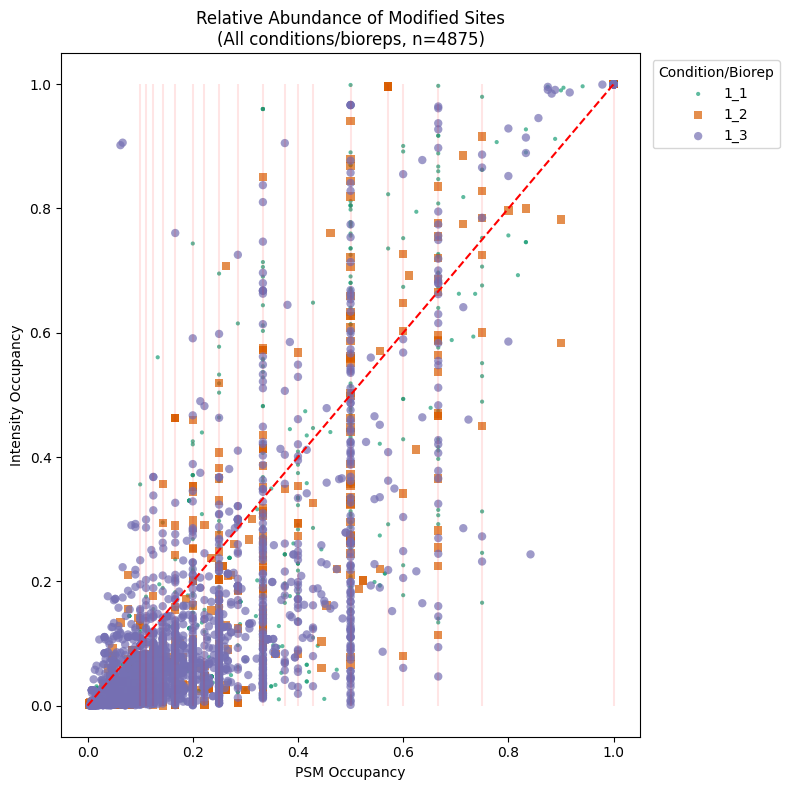

In [ ]:
scatter_cmap = plt.get_cmap('Dark2')

fig, ax = plt.subplots(figsize=(8, 8), dpi=100)
# Ensure these are available even if later cells were not run yet
cond_biorep_set = sorted(set(cond_biorep_labels))
marker_list = [m for m in markers if m not in ("None", "none", " ", "")]

ax.vlines(list(map(lambda x: x[0]/x[1], fractions)), 0, 1, color='red', alpha=0.1)

for i, cb in enumerate(cond_biorep_set):
    idx = [j for j, label in enumerate(cond_biorep_labels) if label == cb]
    ax.scatter(
        [psm_occs[j] for j in idx],
        [intensity_occs[j] for j in idx],
        alpha=0.7,
        edgecolors="none",
        color=scatter_cmap(i % scatter_cmap.N),
        marker=marker_list[i],
        label=cb
    )
ax.plot([0, 1], [0, 1], 'r--')
ax.set_xlabel("PSM Occupancy")
ax.set_ylabel("Intensity Occupancy")
ax.set_title(f"Relative Abundance of Modified Sites\n(All conditions/bioreps, n={len(psm_occs)})")
ax.legend(title="Condition/Biorep", bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
if save_figures:
    plt.savefig(os.path.join(figure_save_path, "psm_vs_intensity_occupancy.png"), dpi=figure_dpi)


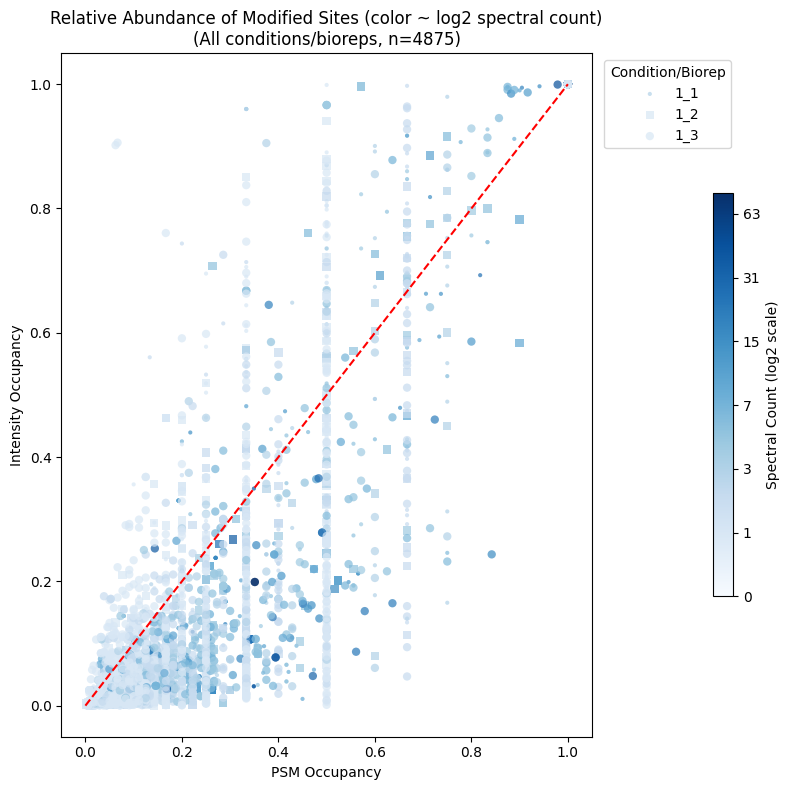

In [ ]:
spectral_counts = np.array([mod.spectral_count for _, _, mod in all_mods], dtype=float)
log2_counts = np.log2(spectral_counts + 1)  # +1 to handle zeros
log2_max = log2_counts.max()
log2_norm = log2_counts / log2_max  # 0..1 on log2 scale

sm = plt.cm.ScalarMappable(cmap='Blues', norm=plt.Normalize(vmin=0, vmax=1))
fig, ax = plt.subplots(figsize=(8, 8), dpi=100)
for i, cb in enumerate(cond_biorep_set):
    idx = [j for j, label in enumerate(cond_biorep_labels) if label == cb]
    colors = [sm.to_rgba(log2_norm[j]) for j in idx]
    ax.scatter(
        [psm_occs[j] for j in idx],
        [intensity_occs[j] for j in idx],
        color=colors,
        edgecolors='none',
        marker=marker_list[i],
        label=cb,
        alpha=0.7
    )
ax.plot([0, 1], [0, 1], 'r--')
ax.set_xlabel("PSM Occupancy")
ax.set_ylabel("Intensity Occupancy")
ax.set_title(f"Relative Abundance of Modified Sites (color ~ log2 spectral count)\n(All conditions/bioreps, n={len(psm_occs)})")
ax.legend(title="Condition/Biorep", bbox_to_anchor=(1.01, 1), loc='upper left')

sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, fraction=0.03, pad=0.18)
cbar.set_label("Spectral Count (log2 scale)")

# Tick positions at powers-of-2 count values mapped back through the log2 normalization
max_count = int(spectral_counts.max())
tick_counts = [2**k - 1 for k in range(int(np.floor(np.log2(max_count + 1))) + 1)]
tick_positions = [np.log2(c + 1) / log2_max for c in tick_counts]
cbar.set_ticks(tick_positions)
cbar.set_ticklabels([str(c) for c in tick_counts])

plt.tight_layout()
if save_figures:
    plt.savefig(os.path.join(figure_save_path, "psm_vs_intensity_occupancy_alpha_spectralcount.png"), dpi=figure_dpi)

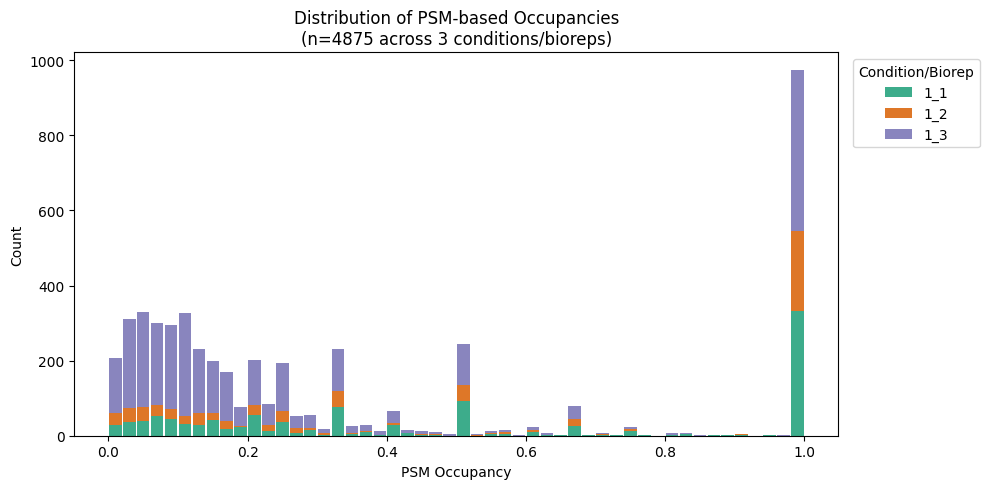

In [ ]:
bins = np.linspace(0, 1, 51)
bin_centers = (bins[:-1] + bins[1:]) / 2
bin_width = bins[1] - bins[0]
cond_biorep_set = list(modified_pgs_per_condbiorep.keys())
cmap = plt.get_cmap('Dark2')

fig, ax = plt.subplots(figsize=(10, 5), dpi=100)
bottoms = np.zeros(len(bin_centers))
for i, cb in enumerate(cond_biorep_set):
    cb_occs = [mod.spectral_count / mod.total_counts_at_position
               for cb_label, _, mod in all_mods if cb_label == cb]
    counts, _ = np.histogram(cb_occs, bins=bins)
    ax.bar(bin_centers, counts, width=bin_width * 0.9, bottom=bottoms,
           color=cmap(i % 10), alpha=0.85, label=cb)
    bottoms += counts

ax.set_xlabel("PSM Occupancy")
ax.set_ylabel("Count")
ax.set_title(f"Distribution of PSM-based Occupancies\n(n={len(psm_occs)} across {len(cond_biorep_set)} conditions/bioreps)")
ax.legend(title="Condition/Biorep", bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
if save_figures:
    plt.savefig(os.path.join(figure_save_path, "psm_occupancy_distribution.png"), dpi=figure_dpi)


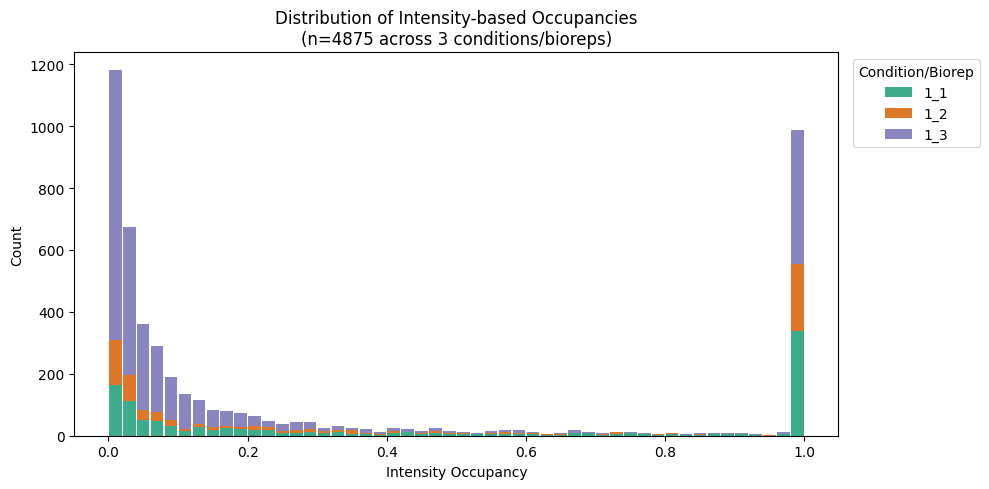

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5), dpi=100)
bottoms = np.zeros(len(bin_centers))
for i, cb in enumerate(cond_biorep_set):
    cb_occs = [mod.intensity / mod.total_intensity_at_position if mod.total_intensity_at_position != 0 else 0
               for cb_label, _, mod in all_mods if cb_label == cb]
    counts, _ = np.histogram(cb_occs, bins=bins)
    ax.bar(bin_centers, counts, width=bin_width * 0.9, bottom=bottoms,
           color=cmap(i % 10), alpha=0.85, label=cb)
    bottoms += counts

ax.set_xlabel("Intensity Occupancy")
ax.set_ylabel("Count")
ax.set_title(f"Distribution of Intensity-based Occupancies\n(n={len(intensity_occs)} across {len(cond_biorep_set)} conditions/bioreps)")
ax.legend(title="Condition/Biorep", bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
if save_figures:
    plt.savefig(os.path.join(figure_save_path, "intensity_occupancy_distribution.png"), dpi=figure_dpi)


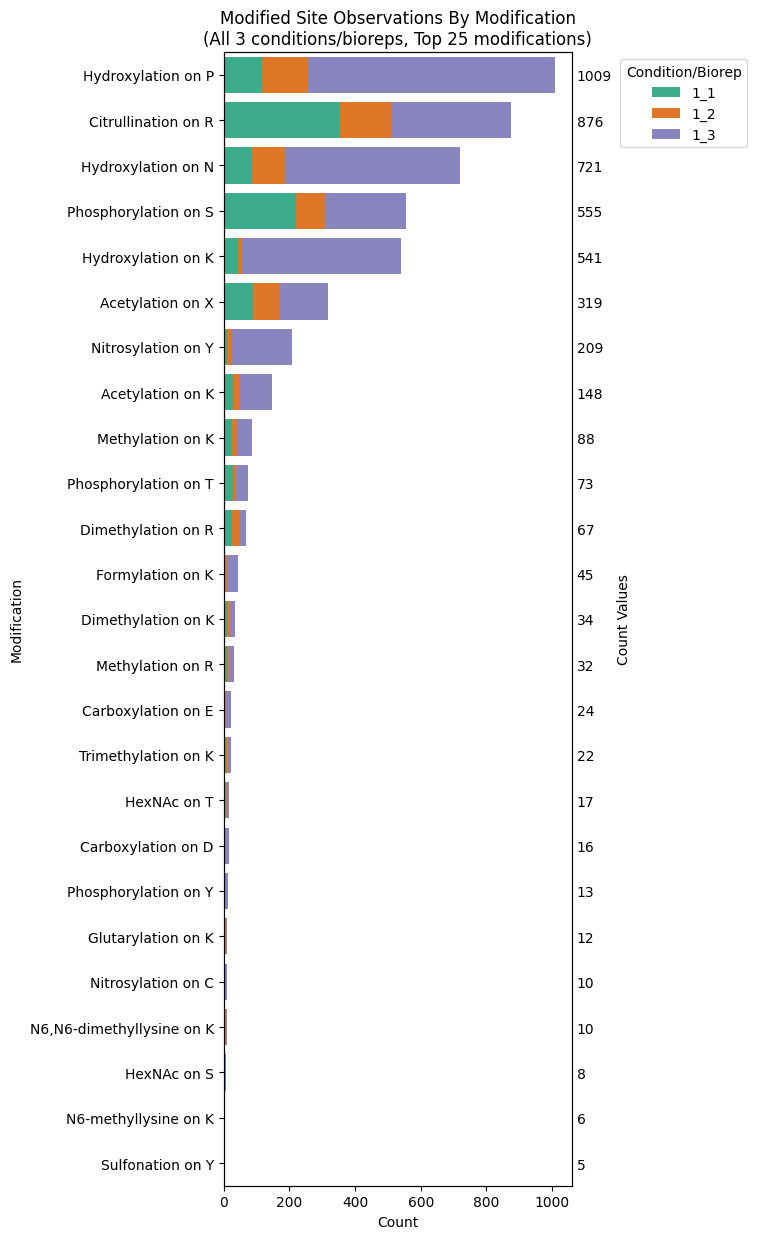

In [ ]:
# Build per-condition/biorep counts for each modification
mod_counts_per_cb = {
    cb: [sum(1 for cb_label, _, mod in all_mods if cb_label == cb and mod.name == m) for m in mod_set]
    for cb in cond_biorep_set
}
total_counts = [sum(mod_counts_per_cb[cb][i] for cb in cond_biorep_set) for i in range(len(mod_set))]

# Sort by total count ascending
TOP_N = 25
order = np.argsort(total_counts)[-TOP_N:]  # top 20 mods
sorted_mods = [mod_set[i] for i in order]
sorted_totals = [total_counts[i] for i in order]

y = np.arange(len(sorted_mods))
fig, ax = plt.subplots(figsize=(8, max(8, len(sorted_mods) * 0.5)), dpi=100)

lefts = np.zeros(len(sorted_mods))
for j, cb in enumerate(cond_biorep_set):
    cb_counts = np.array([mod_counts_per_cb[cb][i] for i in order])
    ax.barh(y, cb_counts, left=lefts, color=cmap(j % 10), alpha=0.85, label=cb)
    lefts += cb_counts

ax.set_yticks(y)
ax.set_yticklabels(sorted_mods)
ax.set_xlabel('Count')
ax.set_ylabel('Modification')
ax.set_ylim(-0.5, len(sorted_mods) - 0.5)

ax2 = ax.twinx()
ax2.set_ylabel('Count Values')
ax2.set_ylim(ax.get_ylim())
ax2.set_yticks(y)
ax2.set_yticklabels(sorted_totals)
ax2.tick_params(axis='y', length=0)

ax.legend(title="Condition/Biorep", bbox_to_anchor=(1.12, 1), loc='upper left')
plt.title(f"Modified Site Observations By Modification\n(All {len(cond_biorep_set)} conditions/bioreps, Top {TOP_N} modifications)")
plt.tight_layout()
if save_figures:
    plt.savefig(os.path.join(figure_save_path, "modification_counts.png"), dpi=figure_dpi)


In [ ]:
summary_path = os.path.join(figure_save_path, "figure_generation_summary.md")
summary_dir = os.path.dirname(summary_path)
include_figures_in_summary = True  # Set to False to omit embedded figures from the markdown report
use_dedicated_pdf_figure_pages = True  # Put each figure and legend on its own PDF page

figure_descriptions = {
    "psm_vs_intensity_occupancy.png": (
        "PSM-based versus intensity-based modification site occupancy. "
        "Each point represents a single modified site observation across all conditions and biological replicates, "
        "colored by condition/biorep. Occupancy is defined as the ratio of modified spectral counts (x-axis) "
        "or modified peptide intensity (y-axis) to the total at each site. "
        "The dashed red line indicates perfect agreement (y = x); deviations reflect differences between "
        "spectral count- and intensity-based occupancy estimates."
    ),
    "psm_vs_intensity_occupancy_alpha_spectralcount.png": (
        "PSM-based versus intensity-based modification site occupancy, with point color scaled by "
        "log2(spectral count + 1). Points with higher spectral counts appear darker blue, "
        "reflecting greater quantification confidence. The dashed red line indicates perfect agreement (y = x). "
        "The color bar indicates the range of spectral counts across all observations."
    ),
    "psm_occupancy_distribution.png": (
        "Distribution of PSM-based modification site occupancies across all observed modified sites. "
        "Occupancy is calculated as the ratio of modified spectral counts to total spectral counts at each site. "
        "Bars are stacked by condition/biological replicate and binned in increments of 0.05 over the range [0, 1]."
    ),
    "intensity_occupancy_distribution.png": (
        "Distribution of intensity-based modification site occupancies across all observed modified sites. "
        "Occupancy is calculated as the ratio of modified peptide intensity to total peptide intensity at each site. "
        "Bars are stacked by condition/biological replicate and binned in increments of 0.05 over the range [0, 1]."
    ),
    "modification_counts.png": (
        "Number of modified site observations per modification type, stratified by condition and biological replicate. "
        "Modifications are sorted by total observation count (ascending, left axis). "
        "Total counts summed across all conditions and biological replicates are shown on the right axis."
    ),
}

# Dataset-level stats
n_rows, n_cols = df.shape
q_thresh = Q_Value_threshold if "Q_Value_threshold" in globals() else 0.01
n_qpass = int((df["Protein QValue"] <= q_thresh).sum())
n_occ_cols = len(occupancy_columns)
cond_list = sorted(list(conditions))
biorep_list = sorted(list(bioreps))
n_total_mods = len(all_mods)
n_unique_sites = len(set((protein, mod.position) for _, pgs in modified_pgs_per_condbiorep.items() for pg in pgs for protein, mods in pg.modifications.items() for mod in mods))
n_unique_mod_types = len(mod_set)

# Occupancy summary
psm_arr = np.array(psm_occs, dtype=float)
int_arr = np.array(intensity_occs, dtype=float)

# Correlation analysis (pooled and per condition/biorep)
corr_df = pd.DataFrame({
    "cond_biorep": cond_biorep_labels,
    "psm": psm_arr,
    "intensity": int_arr,
})

pearson_all = corr_df["psm"].corr(corr_df["intensity"], method="pearson")
spearman_all = corr_df["psm"].corr(corr_df["intensity"], method="spearman")

corr_lines = [
    f"- Pooled (all condition/biorep): Pearson r = **{pearson_all:.4f}**, Spearman rho = **{spearman_all:.4f}**, n = **{len(corr_df)}**"
]

for cb_key in sorted(corr_df["cond_biorep"].unique()):
    cb_df = corr_df[corr_df["cond_biorep"] == cb_key]
    n_cb = len(cb_df)
    if n_cb < 2:
        corr_lines.append(f"- {cb_key}: insufficient data for correlation (n = {n_cb})")
        continue

    pearson_cb = cb_df["psm"].corr(cb_df["intensity"], method="pearson")
    spearman_cb = cb_df["psm"].corr(cb_df["intensity"], method="spearman")

    if pd.isna(pearson_cb) or pd.isna(spearman_cb):
        corr_lines.append(f"- {cb_key}: correlation undefined (likely zero variance), n = {n_cb}")
    else:
        corr_lines.append(
            f"- {cb_key}: Pearson r = **{pearson_cb:.4f}**, Spearman rho = **{spearman_cb:.4f}**, n = **{n_cb}**"
        )

# Per condition/biorep modified PG counts
cb_lines = []
for cb_key in sorted(modified_pgs_per_condbiorep.keys()):
    n_mod_pg = len(modified_pgs_per_condbiorep[cb_key])
    n_detected_pg = int(((df[f"SpectralCount_{cb_key}"] > 0) & (df["Protein QValue"] <= q_thresh)).sum())
    cb_lines.append(f"- {cb_key}: {n_mod_pg} modified PGs / {n_detected_pg} detected PGs (Q<={q_thresh})")

# Top modifications (by total count)
top_n = 10
top_mods = list(zip(sorted_mods[::-1][:top_n], sorted_totals[::-1][:top_n]))

figure_entries = []
fig_lines = []
pdf_fig_lines = []
for fname, desc in figure_descriptions.items():
    fpath = os.path.join(figure_save_path, fname)
    exists = os.path.exists(fpath)
    size_kb = (os.path.getsize(fpath) / 1024) if exists else 0
    image_relpath = os.path.relpath(fpath, start=summary_dir).replace("\\", "/")

    figure_entries.append({
        "name": fname,
        "desc": desc,
        "exists": exists,
        "size_kb": size_kb,
        "image_relpath": image_relpath,
    })

for entry in figure_entries:
    fname = entry["name"]
    desc = entry["desc"]
    exists = entry["exists"]
    size_kb = entry["size_kb"]
    image_relpath = entry["image_relpath"]

    status_line = f"- `{fname}`: {'FOUND' if exists else 'MISSING'}" + (f" ({size_kb:.1f} KB)" if exists else "")
    fig_lines.append(status_line)
    fig_lines.append(f"  - {desc}")
    pdf_fig_lines.append(status_line)
    pdf_fig_lines.append(f"  - {desc}")

    if include_figures_in_summary and exists:
        fig_lines.append("")
        fig_lines.append(f"  ![{fname}]({image_relpath})")
        fig_lines.append("")


def build_report(figure_section_lines: list[str]) -> str:
    return f"""# Figure Summary

## 1) Figure generation details

Output folder: `{figure_save_path}`

Generated figures:
{chr(10).join(figure_section_lines)}

## 2) Dataset statistics

- Source file: `{fn}`
- DataFrame shape: **{n_rows} rows x {n_cols} columns**
- Q-value threshold used: **{q_thresh}**
- Protein groups passing Q-value threshold: **{n_qpass}**
- Occupancy columns detected: **{n_occ_cols}**
- Has IntensityOccupancy columns: **{has_intensity_occupancy}**
- Conditions: **{cond_list}**
- Biological replicates: **{biorep_list}**

Modification-level summary:
- Total observed modified sites (all condition/biorep): **{n_total_mods}**
- Unique modified protein-position sites: **{n_unique_sites}**
- Unique modification types: **{n_unique_mod_types}**

Per condition/biorep modified PG coverage:
{chr(10).join(cb_lines)}

Occupancy summary (all modifications pooled):
- PSM occupancy mean ± std: **{psm_arr.mean():.4f} ± {psm_arr.std():.4f}**
- PSM occupancy median [min, max]: **{np.median(psm_arr):.4f} [{psm_arr.min():.4f}, {psm_arr.max():.4f}]**
- Intensity occupancy mean ± std: **{int_arr.mean():.4f} ± {int_arr.std():.4f}**
- Intensity occupancy median [min, max]: **{np.median(int_arr):.4f} [{int_arr.min():.4f}, {int_arr.max():.4f}]**

Correlation analysis (PSM occupancy vs intensity occupancy):
{chr(10).join(corr_lines)}

Top {top_n} modification types by count:
{chr(10).join([f"- {name}: {count}" for name, count in top_mods])}
"""


report = build_report(fig_lines)
report_for_pdf = build_report(pdf_fig_lines)

if save_summary:
    with open(summary_path, "w", encoding="utf-8") as f:
        f.write(report)

print(f"Summary written to: {summary_path}")

pdf_css = """
img {
    display: block;
    width: 100%;
    max-width: 100%;
    height: auto;
    margin: 12pt auto 0 auto;
}
p {
    margin: 6pt 0;
}
h1, h2, h3 {
    margin-bottom: 8pt;
}
"""

_pdf = MarkdownPdf(toc_level=2)
_pdf.add_section(MdSection(report_for_pdf, root=summary_dir), user_css=pdf_css)

if use_dedicated_pdf_figure_pages:
    for entry in figure_entries:
        if not entry["exists"]:
            continue

        figure_page = f"""## {entry['name']}

{entry['desc']}

<img src=\"{entry['image_relpath']}\" alt=\"{entry['name']}\" />
"""
        _pdf.add_section(
            MdSection(
                figure_page,
                root=summary_dir,
                borders=(48, 48, -48, -48),
            ),
            user_css=pdf_css,
        )

if save_summary:
    _pdf.save(os.path.splitext(summary_path)[0] + ".pdf")
    print(f"PDF written to: {os.path.splitext(summary_path)[0] + '.pdf'}")


Summary written to: C:\Users\student\Desktop\Mann11CellLines_HelaOnly_RawOnly\All18rawfiles\2026-04-07-16-56-28\Figures\figure_generation_summary.md
PDF written to: C:\Users\student\Desktop\Mann11CellLines_HelaOnly_RawOnly\All18rawfiles\2026-04-07-16-56-28\Figures\figure_generation_summary.pdf
